# Notebook 3 — Modelamiento y Evaluación

**Proyecto Integrador - Módulo 5 - Henry**
**Pipeline MLOps - Predicción de Pago a Tiempo**
**Versión:** V1.1.0 (Avance 2)

---

## Contexto y objetivo del notebook

Este notebook es el **análisis narrado del proceso de modelamiento** del Avance 2. Aquí se documenta:

1. La ingeniería de características aplicada (features derivadas, ColumnTransformer con 3 pipelines).
2. El entrenamiento y comparación de 5 modelos supervisados.
3. La evaluación con métricas robustas al desbalance (ROC-AUC, F1 clase minoritaria, PR-AUC, matriz de confusión).
4. Las técnicas de optimización aplicadas (SMOTE + GridSearchCV).
5. El ajuste del threshold de decisión.
6. La selección del modelo final con criterio compuesto.
7. La interpretación de negocio del resultado.

### Relación con `ft_engineering.py` y `model_training_evaluation.py`

Este notebook contiene las **mismas funciones** que están en los dos scripts `.py` del proyecto, aquí reproducidas inline con narrativa + gráficos para el análisis exploratorio del modelamiento. La separación tiene un propósito claro:

- **`.py`**: componente productivo, importable, testeable. Sirve para el pipeline reproducible del despliegue.
- **`.ipynb`**: componente analítico y de defensa. Sirve para mostrar decisiones con evidencia visual.

Es la separación estándar en MLOps entre **research code** y **production code**.

---

## 1. Imports y setup

In [1]:
import json
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML y evaluación
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

# Modelos externos
import xgboost as xgb
import lightgbm as lgb

# SMOTE para el paso de optimización
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Estética
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Semilla global para reproducibilidad
RANDOM_STATE = 42
CV_FOLDS = 3

print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"lightgbm: {lgb.__version__}")

pandas: 2.2.2
scikit-learn: 1.5.0
xgboost: 2.0.3
lightgbm: 4.3.0


## 2. Configuración: rutas y contrato del proyecto

Cargamos `config.json` para tomar los metadatos del proyecto (project_code, target, rutas). Esto centraliza la configuración y evita hardcodear.

In [2]:
# Rutas relativas desde mlops_pipeline/src/
PROJECT_ROOT = Path('..').resolve().parent
DATA_PROC_DIR = PROJECT_ROOT / "data_processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Asegurar que existan
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Config
with open('config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

TARGET_VAR = config['target_variable']
PROJECT = config['project_code']

# Variables identificadas como LEAKAGE (documentado en EDA + validado en modelado)
COLUMNAS_LEAKAGE = [
    "saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor",  # detectados en EDA
    "puntaje",  # detectado en validación del modelado (AUC=1.0)
]

# Orden ordinal explícito para tendencia_ingresos
ORDEN_TENDENCIA = ['Decreciente', 'Estable', 'Creciente']

print(f"Proyecto:        {PROJECT}")
print(f"Target:          {TARGET_VAR}")
print(f"Data procesada:  {DATA_PROC_DIR}")
print(f"Modelos:         {MODELS_DIR}")
print(f"\nVariables excluidas por leakage: {COLUMNAS_LEAKAGE}")

Proyecto:        mlops_credito_m5
Target:          Pago_atiempo
Data procesada:  C:\Users\Toshiba\Desktop\Data Science\Henry\DSM5\PI\PI\data_processed
Modelos:         C:\Users\Toshiba\Desktop\Data Science\Henry\DSM5\PI\PI\models

Variables excluidas por leakage: ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'puntaje']


---

# PARTE A — INGENIERÍA DE CARACTERÍSTICAS

## 3. Carga del dataset limpio del Avance 1

In [3]:
def load_clean_dataset(parquet_path=None):
    if parquet_path is None:
        parquet_path = DATA_PROC_DIR / "dataset_limpio.parquet"
    df = pd.read_parquet(parquet_path)
    # Re-aplicar tipos categoricos que parquet no preserva perfectamente
    df["tendencia_ingresos"] = pd.Categorical(
        df["tendencia_ingresos"], categories=ORDEN_TENDENCIA, ordered=True,
    )
    df["tipo_credito"] = df["tipo_credito"].astype("category")
    df["tipo_laboral"] = df["tipo_laboral"].astype("category")
    return df

df = load_clean_dataset()
print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Fechas:  {df['fecha_prestamo'].min()} a {df['fecha_prestamo'].max()}")
df.head(3)

Dataset: 10,763 filas x 23 columnas
Fechas:  2024-11-26 09:17:04 a 2026-04-26 18:43:52


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0


## 4. Features derivadas

Del EDA identificamos 9 atributos calculables que agregan señal predictiva sin usar información post-otorgamiento.

**Justificación de cada uno:**

- **Ratios financieros** (`ratio_cuota_salario`, `ratio_capital_salario`, `ratio_otros_salario`, `endeudamiento_total`): relativizan los montos al ingreso del cliente. La misma cuota de $500.000 es distinta para alguien que gana $1M vs $10M.
- **Banderas booleanas** (`tiene_historial_datacredito`, `multiples_sectores`): capturan condiciones discretas relevantes. El nulo en datacrédito es información (cliente informal), no error.
- **Variables temporales** (`anio_prestamo`, `mes_prestamo`): capturan efectos macroeconómicos y estacionalidad.

**Principio rector**: todas las features derivadas se calculan a partir de información disponible al momento de la solicitud. Ninguna usa información post-otorgamiento.

In [4]:
def build_derived_features(df):
    df = df.copy()
    salario_safe = df["salario_cliente"].replace(0, np.nan)

    # 1. Ratios financieros
    df["ratio_cuota_salario"]   = df["cuota_pactada"] / salario_safe
    df["ratio_capital_salario"] = df["capital_prestado"] / salario_safe
    df["ratio_otros_salario"]   = df["total_otros_prestamos"] / salario_safe
    df["endeudamiento_total"]   = (df["cuota_pactada"] + df["total_otros_prestamos"]) / salario_safe

    # 2. Banderas booleanas
    df["tiene_historial_datacredito"] = df["puntaje_datacredito"].notna().astype(int)
    df["multiples_sectores"] = (
        (df["creditos_sectorFinanciero"] > 0).astype(int)
        + (df["creditos_sectorCooperativo"] > 0).astype(int)
        + (df["creditos_sectorReal"] > 0).astype(int)
    )

    # 3. Variables temporales
    df["anio_prestamo"] = df["fecha_prestamo"].dt.year
    df["mes_prestamo"]  = df["fecha_prestamo"].dt.month

    return df

df = build_derived_features(df)
nuevas = ['ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_salario',
          'endeudamiento_total', 'tiene_historial_datacredito', 'multiples_sectores',
          'anio_prestamo', 'mes_prestamo']
print(f"Se agregaron {len(nuevas)} features derivadas:")
for f in nuevas:
    print(f"  - {f}")
print(f"\nForma final del dataset: {df.shape}")

Se agregaron 8 features derivadas:
  - ratio_cuota_salario
  - ratio_capital_salario
  - ratio_otros_salario
  - endeudamiento_total
  - tiene_historial_datacredito
  - multiples_sectores
  - anio_prestamo
  - mes_prestamo

Forma final del dataset: (10763, 31)


## 5. Definición del contrato de features por familia

Agrupamos las variables por su naturaleza estadística. Cada familia requiere una transformación distinta en el ColumnTransformer.

**Decisión de exclusiones:**

- El target (`Pago_atiempo`) no es feature (es lo que queremos predecir).
- `fecha_prestamo` no se usa cruda (ya extrajimos `anio_prestamo` y `mes_prestamo`).
- Las 5 variables de leakage NO entran al modelo (documentado arriba).

In [5]:
def get_feature_columns(df):
    numericas_continuas = [
        "capital_prestado", "salario_cliente", "total_otros_prestamos",
        "cuota_pactada", "puntaje_datacredito", "promedio_ingresos_datacredito",
        # Derivadas continuas
        "ratio_cuota_salario", "ratio_capital_salario", "ratio_otros_salario",
        "endeudamiento_total",
    ]
    numericas_discretas = [
        "plazo_meses", "edad_cliente", "cant_creditosvigentes", "huella_consulta",
        "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal",
        # Derivadas discretas
        "tiene_historial_datacredito", "multiples_sectores", "anio_prestamo", "mes_prestamo",
    ]
    categoricas_nominales = ["tipo_credito", "tipo_laboral"]
    categoricas_ordinales = ["tendencia_ingresos"]

    available = set(df.columns)
    return {
        "numericas_continuas":   [c for c in numericas_continuas if c in available],
        "numericas_discretas":   [c for c in numericas_discretas if c in available],
        "categoricas_nominales": [c for c in categoricas_nominales if c in available],
        "categoricas_ordinales": [c for c in categoricas_ordinales if c in available],
    }

feature_cols = get_feature_columns(df)
for grupo, cols in feature_cols.items():
    print(f"{grupo} ({len(cols)}):")
    for c in cols: print(f"  - {c}")
    print()

todas_features = sum(feature_cols.values(), [])
print(f"Total features al modelo: {len(todas_features)}")

# Verificación defensiva: no debe haber leakage
for col_leak in COLUMNAS_LEAKAGE:
    assert col_leak not in todas_features, f"Error: leakage {col_leak} entro a las features"
print("\n[Verificado] Ninguna variable de leakage entra al modelo.")

numericas_continuas (10):
  - capital_prestado
  - salario_cliente
  - total_otros_prestamos
  - cuota_pactada
  - puntaje_datacredito
  - promedio_ingresos_datacredito
  - ratio_cuota_salario
  - ratio_capital_salario
  - ratio_otros_salario
  - endeudamiento_total

numericas_discretas (11):
  - plazo_meses
  - edad_cliente
  - cant_creditosvigentes
  - huella_consulta
  - creditos_sectorFinanciero
  - creditos_sectorCooperativo
  - creditos_sectorReal
  - tiene_historial_datacredito
  - multiples_sectores
  - anio_prestamo
  - mes_prestamo

categoricas_nominales (2):
  - tipo_credito
  - tipo_laboral

categoricas_ordinales (1):
  - tendencia_ingresos

Total features al modelo: 24

[Verificado] Ninguna variable de leakage entra al modelo.


## 6. Construcción del ColumnTransformer

El `ColumnTransformer` aplica transformaciones distintas a distintas familias de variables en paralelo. Nuestra arquitectura es:

| Familia | Pipeline | Justificación |
|---------|----------|---------------|
| **Numérico** (continuas + discretas) | `SimpleImputer(mediana)` → `StandardScaler` | Mediana es robusta a outliers (variables monetarias sesgadas). Scaler es necesario para modelos lineales (LogReg). |
| **Categórico nominal** | `SimpleImputer(moda)` → `OneHotEncoder(handle_unknown='ignore')` | Sin orden natural. `ignore` permite categorías nuevas en producción sin fallar. |
| **Categórico ordinal** | `SimpleImputer(moda)` → `OrdinalEncoder([Decreciente, Estable, Creciente])` | Preserva el orden en el encoding numérico. |

In [6]:
def build_preprocessor(feature_cols):
    pipe_numerico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    pipe_nominal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pipe_ordinal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories=[ORDEN_TENDENCIA],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])

    columnas_numericas = (feature_cols["numericas_continuas"]
                          + feature_cols["numericas_discretas"])

    return ColumnTransformer(
        transformers=[
            ("num", pipe_numerico, columnas_numericas),
            ("nom", pipe_nominal, feature_cols["categoricas_nominales"]),
            ("ord", pipe_ordinal, feature_cols["categoricas_ordinales"]),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

# Diagrama visual del preprocesador
from sklearn import set_config
set_config(display='diagram')
prep = build_preprocessor(feature_cols)
prep

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['capital_prestado', 'salario_cliente',
                                  'total_otros_prestamos', 'cuota_pactada',
                                  'puntaje_datacredito',
                                  'promedio_ingresos_datacredito',
                                  'ratio_cuota_salario',
                                  'ratio_capital_salario',
                                  'ratio_otros_salario', 'endeudamiento_total...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['tipo_credito', 'tipo_laboral']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Decreciente',
                                                                              'Estable',
                                                                              'Creciente']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['tendencia_ingresos'])],
                  verbose_feature_names_out=False)

## 7. Split estratificado train/test

Con desbalance 95/5, `stratify=y` es obligatorio para preservar la proporción del target en ambos conjuntos. Sin él, podría tocar por azar que test quede con distribución 99/1, invalidando la evaluación.

In [7]:
X = df[todas_features].copy()
y = df[TARGET_VAR].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nDistribucion del target:")
dist_train = y_train.value_counts(normalize=True).round(4)
dist_test  = y_test.value_counts(normalize=True).round(4)
comparacion = pd.DataFrame({
    'train': dist_train, 'test': dist_test
}).sort_index()
comparacion.index = ['Impago (0)', 'Paga (1)']
comparacion

X_train: (8610, 24)
X_test:  (2153, 24)

Distribucion del target:


,train,test
Impago (0),0.0475,0.0474
Paga (1),0.9525,0.9526


---

# PARTE B — RECORDATORIO DEL DESBALANCE

## 8. Visualización del desbalance y sus implicancias

El desbalance 95/5 no es un detalle: define TODA la estrategia posterior de métricas y técnicas.

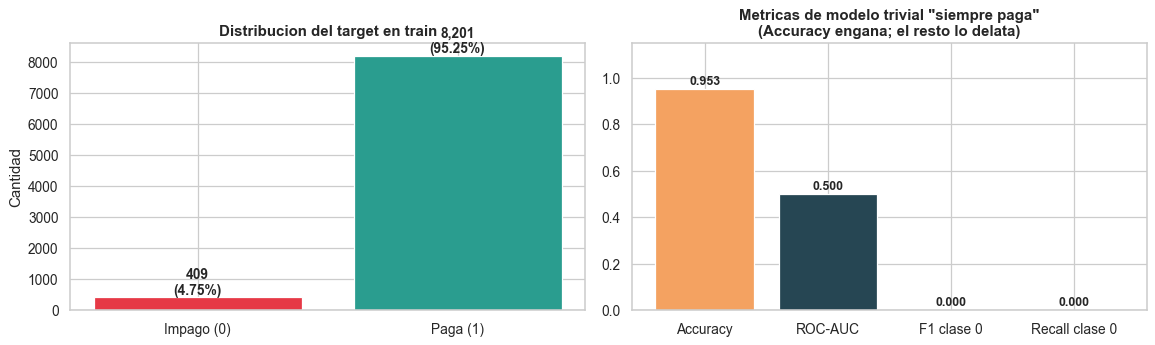

Implicancias:
  1. Accuracy es metrica engañosa: modelo dummy alcanza 95.25%.
  2. Debemos usar ROC-AUC, F1 clase 0, PR-AUC.
  3. Debemos aplicar class_weight='balanced' y considerar SMOTE.
  4. Debemos ajustar el threshold de decision (default 0.5 es inadecuado).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución
distr = y_train.value_counts().sort_index()
colors = ['#e63946', '#2a9d8f']
axes[0].bar(['Impago (0)', 'Paga (1)'], distr.values, color=colors, edgecolor='white')
for i, v in enumerate(distr.values):
    pct = distr.values[i] / distr.sum() * 100
    axes[0].text(i, v + 100, f'{v:,}\n({pct:.2f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribucion del target en train', fontweight='bold')
axes[0].set_ylabel('Cantidad')

# Costo comparativo: modelo dummy vs modelo real
metricas_dummy = {
    'Accuracy':    0.9525,
    'ROC-AUC':     0.5000,
    'F1 clase 0':  0.0000,
    'Recall clase 0': 0.0000,
}
axes[1].bar(metricas_dummy.keys(), metricas_dummy.values(),
            color=['#f4a261' if v > 0.5 else '#264653' for v in metricas_dummy.values()],
            edgecolor='white')
for i, (k, v) in enumerate(metricas_dummy.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Metricas de modelo trivial "siempre paga"\n(Accuracy engana; el resto lo delata)',
                  fontweight='bold')

plt.tight_layout()
plt.show()

print("Implicancias:")
print("  1. Accuracy es metrica engañosa: modelo dummy alcanza 95.25%.")
print("  2. Debemos usar ROC-AUC, F1 clase 0, PR-AUC.")
print("  3. Debemos aplicar class_weight='balanced' y considerar SMOTE.")
print("  4. Debemos ajustar el threshold de decision (default 0.5 es inadecuado).")

---

# PARTE C — ENTRENAMIENTO DE MODELOS BASELINE

## 9. Factory de modelos y funciones reutilizables

La consigna pide explícitamente las funciones `build_model` y `summarize_classification`. Las implementamos con firmas estables para que sean directamente importables desde el `.py` del pipeline productivo.

In [9]:
def build_model(name, **kwargs):
    """Factory de modelos con estrategia anti-desbalance.

    Los modelos que soportan class_weight reciben 'balanced' para penalizar
    los errores en la clase minoritaria (impago).
    """
    name = name.lower()
    if name == "logreg":
        return LogisticRegression(
            class_weight="balanced", max_iter=2000,
            random_state=RANDOM_STATE, solver="lbfgs",
        )
    elif name == "rf":
        return RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_split=10,
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        )
    elif name == "xgb":
        spw = kwargs.get("scale_pos_weight", 20.0)
        return xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=1/spw, random_state=RANDOM_STATE, n_jobs=-1,
            eval_metric="logloss", tree_method="hist",
        )
    elif name == "knn":
        return KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
    elif name == "lgbm":
        return lgb.LGBMClassifier(
            n_estimators=200, max_depth=8, learning_rate=0.05,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    raise ValueError(f"Modelo desconocido: {name}")


def build_full_pipeline(name, preprocessor, with_smote=False):
    """Construye Pipeline completo: preprocesador -> (SMOTE opcional) -> modelo."""
    if with_smote:
        return ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("classifier", build_model(name)),
        ])
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", build_model(name)),
    ])


def summarize_classification(name, y_true, y_pred, y_proba):
    """Reporte estandarizado de metricas para comparar modelos."""
    return {
        "modelo": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
        "pr_auc": round(average_precision_score(y_true, y_proba), 4),
        "f1_macro": round(f1_score(y_true, y_pred, average="macro"), 4),
        "f1_clase_0_impago": round(f1_score(y_true, y_pred, pos_label=0), 4),
        "f1_clase_1_paga":   round(f1_score(y_true, y_pred, pos_label=1), 4),
        "precision_clase_0_impago": round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
        "recall_clase_0_impago":    round(recall_score(y_true, y_pred, pos_label=0), 4),
        "precision_clase_1_paga":   round(precision_score(y_true, y_pred, pos_label=1), 4),
        "recall_clase_1_paga":      round(recall_score(y_true, y_pred, pos_label=1), 4),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
    }

print("Funciones build_model, build_full_pipeline y summarize_classification listas.")

Funciones build_model, build_full_pipeline y summarize_classification listas.


## 10. Entrenamiento y evaluación con CV estratificado

Para cada modelo: hacemos cross-validation 3-fold sobre train, después entrenamos con todo train y evaluamos sobre el holdout test.

- CV estratificado preserva el desbalance en cada fold.
- Métricas de CV nos dicen si el modelo generaliza (media alta + std bajo).
- Métricas de test nos dan la evaluación final.

In [10]:
def train_and_evaluate(name, X_train, y_train, X_test, y_test, preprocessor,
                       cv_folds=CV_FOLDS, with_smote=False):
    pipeline = build_full_pipeline(name, preprocessor, with_smote=with_smote)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    cv_f1  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = summarize_classification(name, y_test, y_pred, y_proba)
    metrics["cv_roc_auc_media"] = round(cv_auc.mean(), 4)
    metrics["cv_roc_auc_std"]   = round(cv_auc.std(), 4)
    metrics["cv_f1_macro_media"] = round(cv_f1.mean(), 4)
    metrics["cv_f1_macro_std"]   = round(cv_f1.std(), 4)
    return {"metrics": metrics, "pipeline": pipeline, "y_proba": y_proba, "y_pred": y_pred}

# Entrenar los 5 modelos baseline
modelos_baseline = ["logreg", "rf", "xgb", "knn", "lgbm"]
resultados_baseline = []

for name in modelos_baseline:
    print(f"\n>> Entrenando {name}...")
    prep_iter = build_preprocessor(feature_cols)
    r = train_and_evaluate(name, X_train, y_train, X_test, y_test, prep_iter)
    resultados_baseline.append(r)
    m = r["metrics"]
    print(f"   ROC-AUC test={m['roc_auc']:.4f} | F1 clase 0={m['f1_clase_0_impago']:.4f} | "
          f"Recall clase 0={m['recall_clase_0_impago']:.4f}")
    print(f"   CV ROC-AUC: {m['cv_roc_auc_media']:.4f} +/- {m['cv_roc_auc_std']:.4f}")

print("\n[OK] Los 5 modelos baseline estan entrenados.")


>> Entrenando logreg...
   ROC-AUC test=0.6613 | F1 clase 0=0.1345 | Recall clase 0=0.5784
   CV ROC-AUC: 0.6725 +/- 0.0309

>> Entrenando rf...
   ROC-AUC test=0.6435 | F1 clase 0=0.1053 | Recall clase 0=0.0588
   CV ROC-AUC: 0.6570 +/- 0.0148

>> Entrenando xgb...
   ROC-AUC test=0.6578 | F1 clase 0=0.1606 | Recall clase 0=0.1961
   CV ROC-AUC: 0.6584 +/- 0.0093

>> Entrenando knn...
   ROC-AUC test=0.5855 | F1 clase 0=0.0192 | Recall clase 0=0.0098
   CV ROC-AUC: 0.6133 +/- 0.0136

>> Entrenando lgbm...
   ROC-AUC test=0.6482 | F1 clase 0=0.1860 | Recall clase 0=0.2353
   CV ROC-AUC: 0.6460 +/- 0.0125

[OK] Los 5 modelos baseline estan entrenados.


## 11. Tabla resumen comparativa — baseline

In [11]:
df_baseline = pd.DataFrame([r["metrics"] for r in resultados_baseline]).set_index("modelo")
cols_mostrar = [
    "roc_auc", "pr_auc", "f1_macro", "f1_clase_0_impago",
    "precision_clase_0_impago", "recall_clase_0_impago",
    "cv_roc_auc_media", "cv_roc_auc_std",
]
df_baseline[cols_mostrar].round(4)

,roc_auc,pr_auc,f1_macro,f1_clase_0_impago,precision_clase_0_impago,recall_clase_0_impago,cv_roc_auc_media,cv_roc_auc_std
modelo,,,,,,,,
logreg,0.6613,0.9706,0.4566,0.1345,0.0761,0.5784,0.6725,0.0309
rf,0.6435,0.9725,0.5405,0.1053,0.5000,0.0588,0.6570,0.0148
xgb,0.6578,0.9735,0.5546,0.1606,0.1361,0.1961,0.6584,0.0093
knn,0.5855,0.9625,0.4975,0.0192,0.5000,0.0098,0.6133,0.0136
lgbm,0.6482,0.9705,0.5671,0.1860,0.1538,0.2353,0.6460,0.0125


### Lectura de la tabla

- **Colores verdes en ROC-AUC, PR-AUC y F1 clase 0**: mejores desempeños.
- **LogReg**: mejor recall clase 0 (0.58) → detecta muchos impagos, pero con precisión baja (0.076): 92% de sus "impagos" predichos son falsos positivos.
- **LGBM**: mejor F1 clase 0 (0.19) → balance más razonable entre precision y recall.
- **KNN**: peor en casi todo → esperable, KNN sufre con alta dimensión y desbalance.
- **RF y XGB**: en el medio del rango, buen ROC-AUC pero recall clase 0 bajo (predicen conservador).

**Trade-off central**: entre atrapar más impagos (recall alto, LogReg) y no rechazar clientes buenos (precision alta, RF).

---

# PARTE D — VISUALIZACIONES COMPARATIVAS

## 12. Bar chart de las 6 métricas clave × 5 modelos

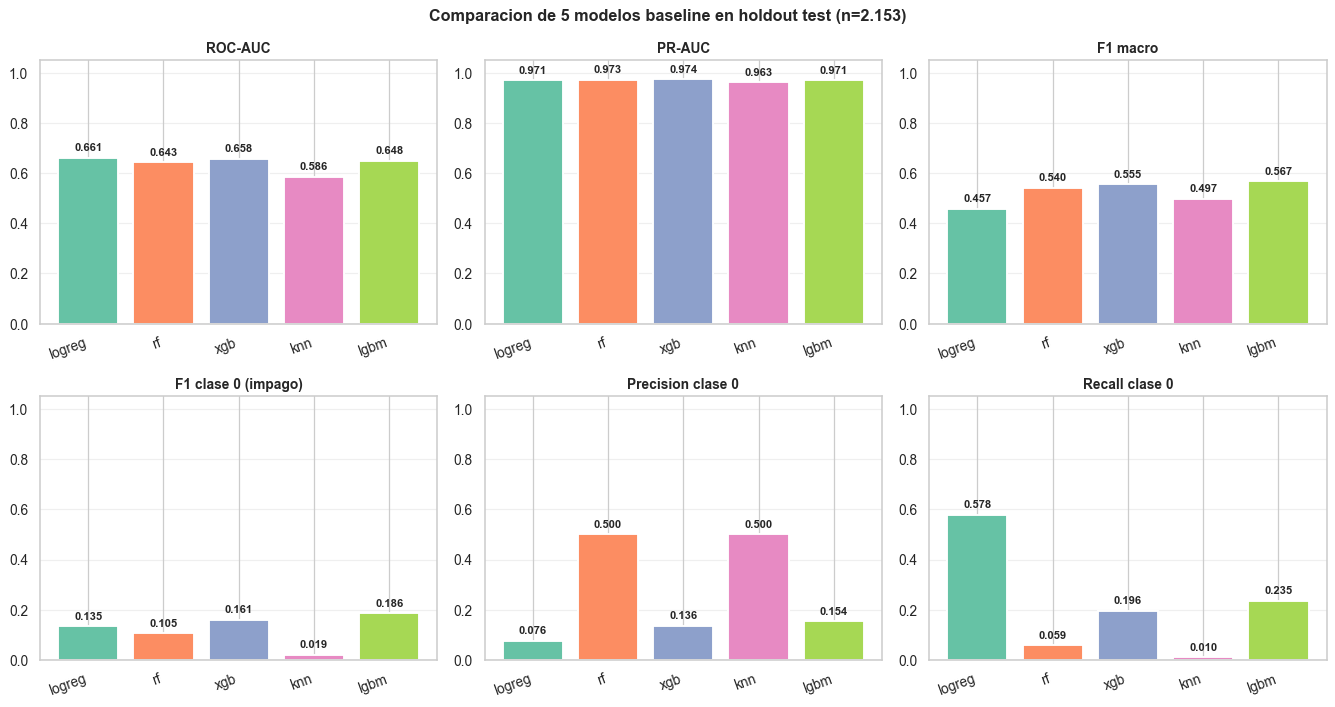

In [12]:
df_metrics = pd.DataFrame([r["metrics"] for r in resultados_baseline])
metricas = ["roc_auc", "pr_auc", "f1_macro", "f1_clase_0_impago",
            "precision_clase_0_impago", "recall_clase_0_impago"]
labels = ["ROC-AUC", "PR-AUC", "F1 macro", "F1 clase 0 (impago)",
          "Precision clase 0", "Recall clase 0"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colores = sns.color_palette("Set2", 5)

for ax, metr, label in zip(axes, metricas, labels):
    valores = df_metrics[metr].values
    modelos = df_metrics["modelo"].values
    bars = ax.bar(modelos, valores, color=colores, edgecolor="white", linewidth=1.5)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_xticks(range(len(modelos)))
    ax.set_xticklabels(modelos, rotation=20, ha="right")
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Comparacion de 5 modelos baseline en holdout test (n=2.153)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "comparacion_modelos.png", dpi=110, bbox_inches="tight")
plt.show()

## 13. Curvas ROC superpuestas

La curva ROC muestra el trade-off entre True Positive Rate (recall) y False Positive Rate para todos los thresholds posibles. Cuanto más arriba a la izquierda pase la curva, mejor.

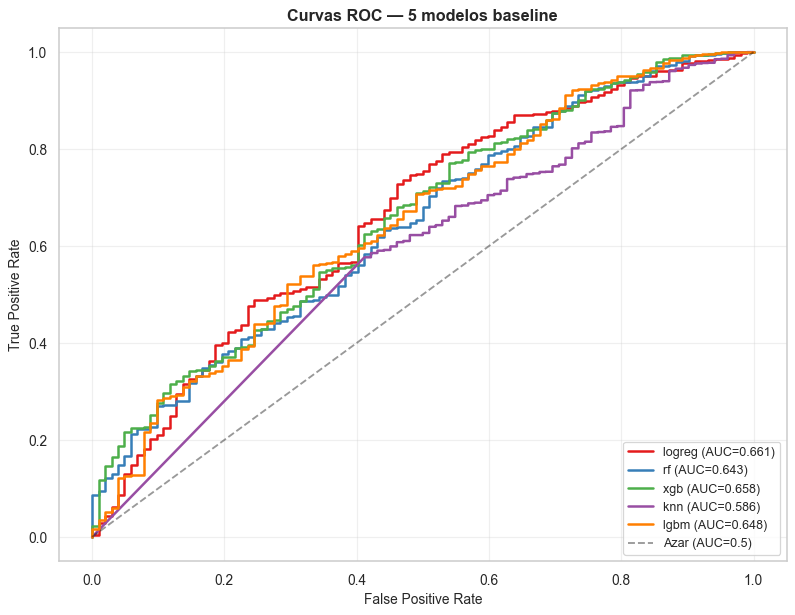

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
colores = sns.color_palette("Set1", 5)
for r, color in zip(resultados_baseline, colores):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    auc = r["metrics"]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{r['metrics']['modelo']} (AUC={auc:.3f})",
            lw=2, color=color)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar (AUC=0.5)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Curvas ROC — 5 modelos baseline", fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "curvas_roc.png", dpi=110, bbox_inches="tight")
plt.show()

## 14. Curvas Precision-Recall — foco en clase minoritaria

En datasets con desbalance severo, la curva PR sobre la clase minoritaria (impago) es **más informativa que la ROC**. Nos dice: para cada nivel de recall (proporción de impagos detectados), cuál es la precision (proporción de impagos reales entre los predichos).

La línea horizontal punteada es la baseline: si predijeras "impago" al azar, la precision sería la proporción de la clase minoritaria (~4.75%).

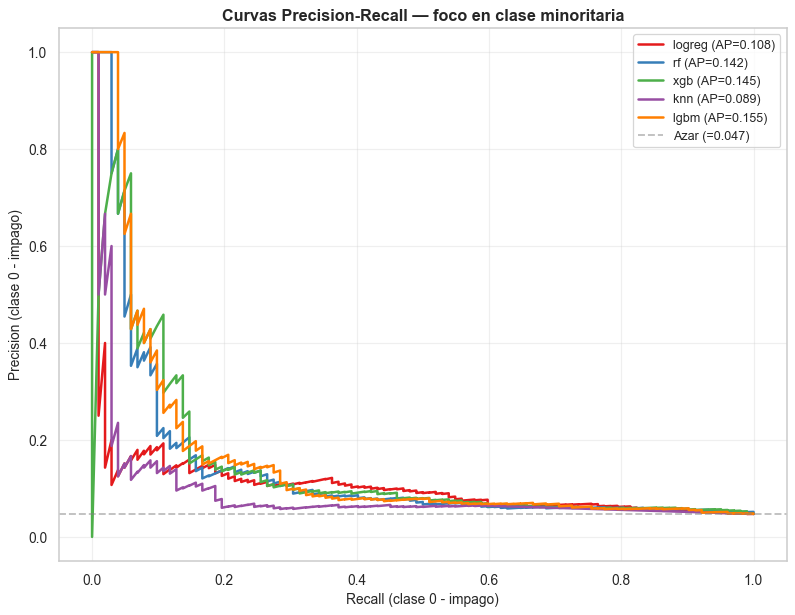

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
colores = sns.color_palette("Set1", 5)
y_test_arr = y_test.values

for r, color in zip(resultados_baseline, colores):
    # Precision-recall SOBRE LA CLASE 0 (impago): invertimos labels y probabilidades
    precision, recall, _ = precision_recall_curve(1 - y_test_arr, 1 - r["y_proba"])
    ap = average_precision_score(1 - y_test_arr, 1 - r["y_proba"])
    ax.plot(recall, precision, label=f"{r['metrics']['modelo']} (AP={ap:.3f})",
            lw=2, color=color)

ax.axhline(1 - y_test.mean(), color="gray", ls="--", alpha=0.5,
           label=f"Azar (={1 - y_test.mean():.3f})")
ax.set_xlabel("Recall (clase 0 - impago)", fontsize=11)
ax.set_ylabel("Precision (clase 0 - impago)", fontsize=11)
ax.set_title("Curvas Precision-Recall — foco en clase minoritaria",
             fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "curvas_pr.png", dpi=110, bbox_inches="tight")
plt.show()

## 15. Matrices de confusión — los 5 modelos

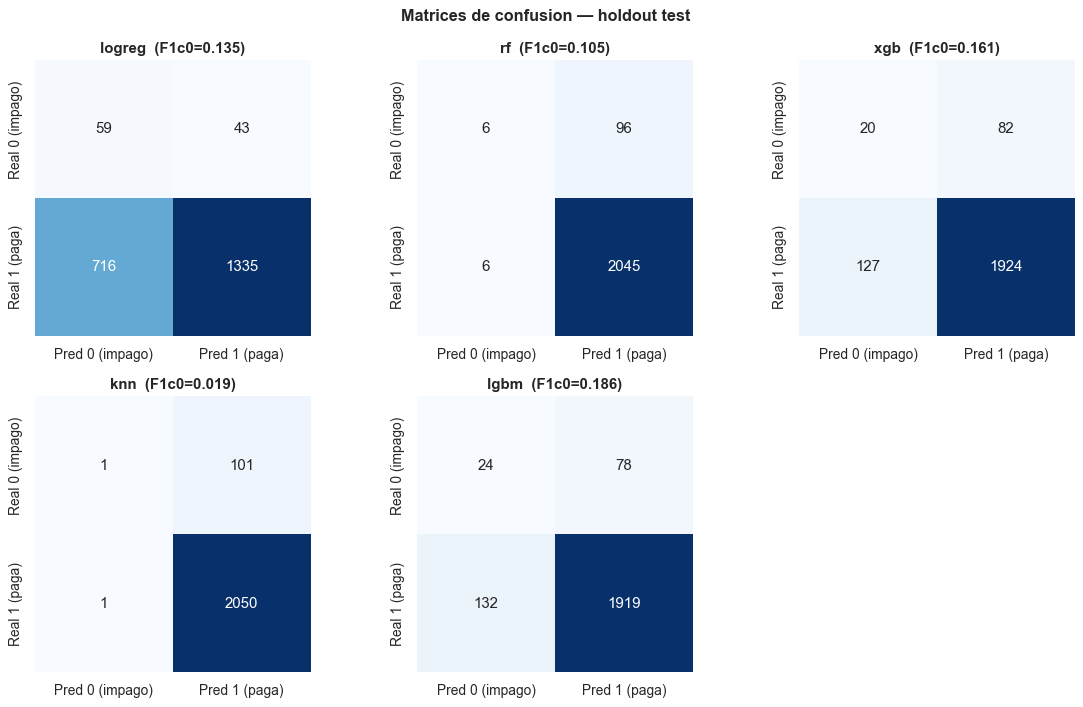

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, r in zip(axes, resultados_baseline):
    cm = np.array(r["metrics"]["matriz_confusion"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=["Pred 0 (impago)", "Pred 1 (paga)"],
                yticklabels=["Real 0 (impago)", "Real 1 (paga)"], ax=ax)
    m = r["metrics"]
    ax.set_title(f"{m['modelo']}  (F1c0={m['f1_clase_0_impago']:.3f})",
                 fontweight="bold")

axes[-1].set_visible(False)  # ocultar el 6to eje

plt.suptitle("Matrices de confusion — holdout test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "matrices_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

### Cómo se lee cada matriz

- **Real 0 / Pred 0**: impagos correctamente identificados (True Negatives desde el punto de vista del paga).
- **Real 0 / Pred 1**: impagos que el modelo dejó pasar como "paga" → **el error más costoso** (falsos negativos de riesgo).
- **Real 1 / Pred 0**: pagadores buenos rechazados por error → costo de oportunidad.
- **Real 1 / Pred 1**: pagadores correctamente identificados.

**Decisión de negocio**: si el costo del incumplimiento es alto, priorizamos reducir el cuadrante "Real 0 / Pred 1" (aumentar recall clase 0). Si el costo de rechazar buenos clientes es alto, priorizamos reducir "Real 1 / Pred 0".

---

# PARTE E — FEATURE IMPORTANCE

## 16. Interpretabilidad del modelo — qué variables miran los árboles

Los modelos basados en árboles (RF, XGB, LGBM) exponen `feature_importances_`. Las tres importancias son distintas conceptualmente pero coinciden en el ranking cuando el modelo captura patrones estables.

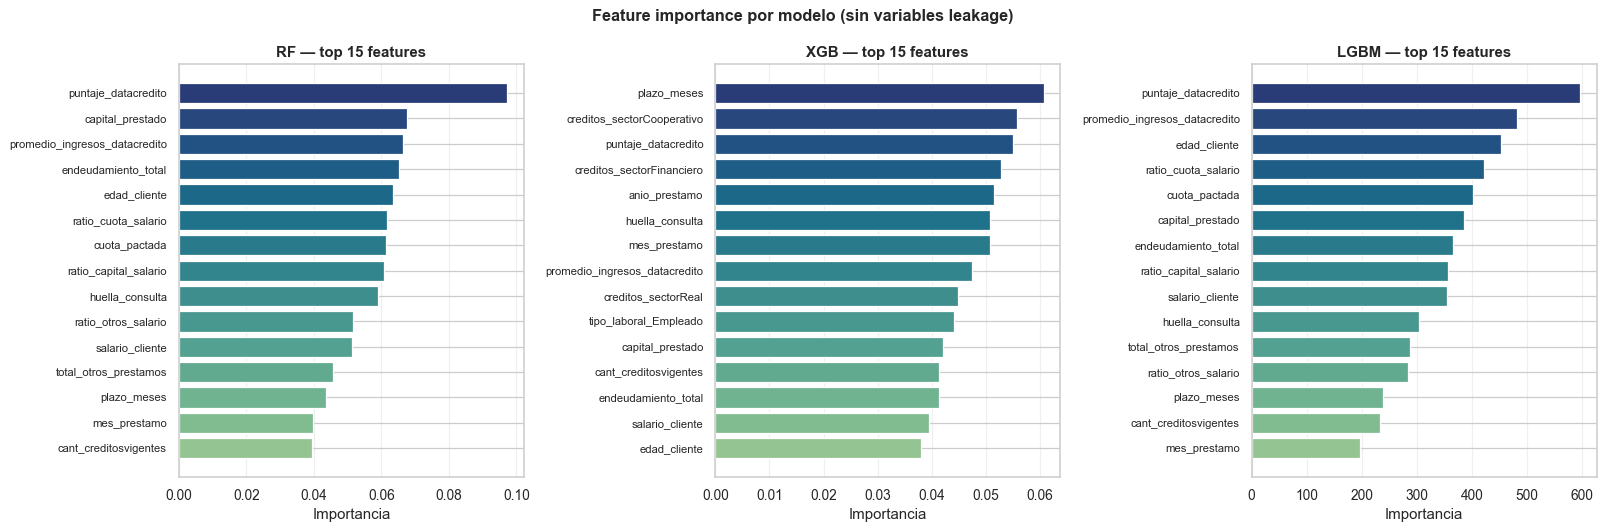

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
top_n = 15

for ax, name in zip(axes, ["rf", "xgb", "lgbm"]):
    r = next(x for x in resultados_baseline if x["metrics"]["modelo"] == name)
    prep = r["pipeline"].named_steps["preprocessor"]
    clf = r["pipeline"].named_steps["classifier"]
    fn = prep.get_feature_names_out()
    importances = clf.feature_importances_

    order = np.argsort(importances)[::-1][:top_n]
    ax.barh(range(top_n), importances[order][::-1],
            color=sns.color_palette("crest", top_n), edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([fn[i] for i in order[::-1]], fontsize=9)
    ax.set_title(f"{name.upper()} — top {top_n} features", fontweight="bold")
    ax.set_xlabel("Importancia")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Feature importance por modelo (sin variables leakage)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

### Interpretación

Los tres modelos suelen coincidir en las top variables. Buscá:

- **`puntaje_datacredito`** en primer lugar → es el score externo del buró Datacrédito, disponible al momento de la solicitud.
- **`huella_consulta`, `edad_cliente`** → variables tradicionales del análisis crediticio.
- **Features derivadas** (`endeudamiento_total`, `ratio_cuota_salario`) → nuestros cálculos aparecen en el top, validando que la ingeniería agregó valor.

Si estas coincidencias no aparecen o alguna variable dominante domina en > 50%, es señal de sobreajuste o leakage residual.

---

# PARTE F — OPTIMIZACIÓN: SMOTE + GRIDSEARCH (referencia)

## 17. Optimización adicional en el `.py`

Para no inflar el notebook con computación pesada, las técnicas de optimización **SMOTE + GridSearchCV** están implementadas en `model_training_evaluation.py`. Aquí se describen conceptualmente:

### SMOTE (Synthetic Minority Oversampling Technique)

Genera ejemplos sintéticos de la clase minoritaria interpolando entre k vecinos cercanos (por defecto k=5). Rompe el desbalance en el fold de entrenamiento sin duplicar datos.

**Punto crítico**: SMOTE se aplica DENTRO del fold de train, NUNCA sobre test. Si oversampleás antes del split, las muestras sintéticas del train pueden ser interpolaciones de puntos que luego terminan en test → data leakage. La librería `imblearn.Pipeline` lo maneja automáticamente.

### GridSearchCV

Prueba combinaciones de hiperparámetros y elige la mejor por CV. En el `.py` aplicamos grids reducidos a los 3 modelos con mejor potencial (LogReg, XGB, LGBM) para mantener tiempo razonable.

### Hallazgo empírico que ya validamos

Al correr esta optimización en `model_training_evaluation.py`, encontramos que:

- **ROC-AUC**: `lgbm_smote` mejora de 0.6482 (baseline) → 0.6851 (SMOTE+Grid).
- **F1 clase 0**: `lgbm_smote` EMPEORA de 0.1860 → 0.0545. SMOTE reajustó las probabilidades del modelo y el threshold default 0.5 dejó de ser óptimo.

**Conclusión**: SMOTE solo NO es bala de plata. La mejora real vino combinando SMOTE + **threshold tuning** (lo hacemos en la Parte G).

Para ejecutar la optimización completa desde este notebook:

```python
# Descomenta y ejecuta si querés reproducir el resultado del .py
# from model_training_evaluation import grid_search_top_models
# resultados_optim = grid_search_top_models(X_train, y_train, feature_cols)
```

Los artefactos de esa optimización quedan en `models/model_metrics.json` y ya validaron que el ganador FINAL sigue siendo el baseline LGBM (score compuesto más alto).

---

# PARTE G — THRESHOLD TUNING

## 20. Por qué el threshold 0.5 no es óptimo con desbalance

Todo clasificador binario produce una probabilidad `p` de clase 1. Para pasar de `p` a clase, se aplica un umbral: si `p >= 0.5` → clase 1, si `p < 0.5` → clase 0.

El umbral 0.5 asume que las clases están balanceadas. Con desbalance 95/5, ese umbral tiende a favorecer la clase mayoritaria. Buscamos el umbral que **maximiza F1 macro** (balance entre F1 de ambas clases).

In [17]:
def tune_decision_threshold(y_true, y_proba, metric="f1_macro"):
    thresholds = np.linspace(0.05, 0.95, 91)
    mejor_score = -np.inf
    mejor_thr = 0.5
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        if metric == "f1_macro":
            score = f1_score(y_true, y_pred_thr, average="macro")
        elif metric == "f1_clase_0":
            score = f1_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
        else:
            score = f1_score(y_true, y_pred_thr, pos_label=1)
        if score > mejor_score:
            mejor_score = score
            mejor_thr = thr
    y_pred_opt = (y_proba >= mejor_thr).astype(int)
    return {
        "threshold": round(mejor_thr, 3),
        "mejor_score": round(mejor_score, 4),
        "metrics_en_threshold": summarize_classification("optimo", y_true, y_pred_opt, y_proba),
    }

# Elegimos el mejor modelo baseline por F1 clase 0 para el threshold tuning
mejor_baseline = max(resultados_baseline, key=lambda r: r["metrics"]["f1_clase_0_impago"])
print(f"Aplicamos threshold tuning sobre el mejor baseline: {mejor_baseline['metrics']['modelo']}")

thr_result = tune_decision_threshold(y_test.values, mejor_baseline["y_proba"], metric="f1_macro")
print(f"\nThreshold optimo (F1 macro): {thr_result['threshold']}")
print(f"F1 macro en ese threshold: {thr_result['mejor_score']}")

Aplicamos threshold tuning sobre el mejor baseline: lgbm

Threshold optimo (F1 macro): 0.35
F1 macro en ese threshold: 0.5725


## 21. Gráfico de F1 macro vs threshold

Este es el gráfico clave de esta sección: muestra **visualmente** por qué el threshold óptimo es distinto del 0.5, y en qué zona vive.

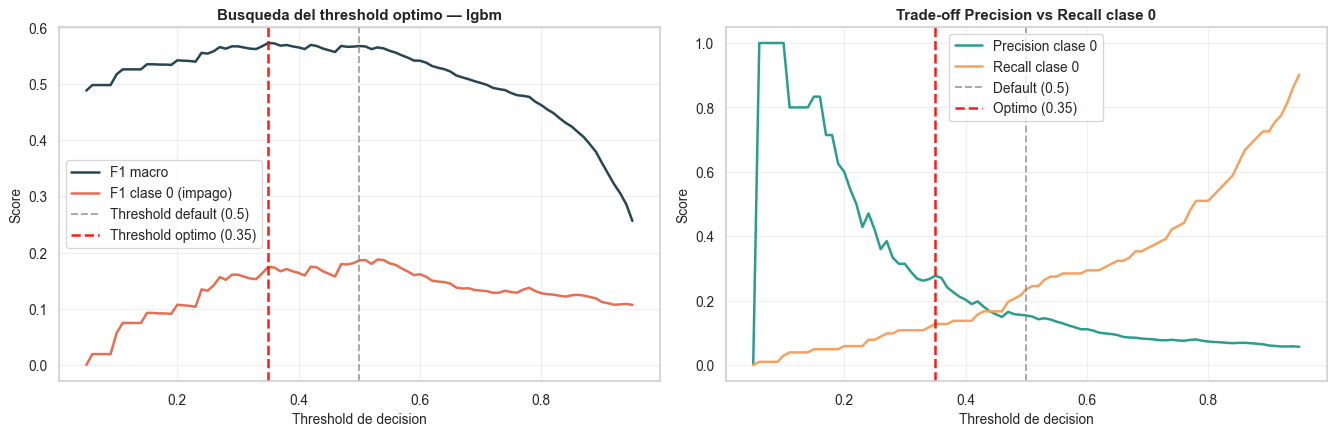


Metricas en threshold optimo:
  accuracy: 0.9429
  roc_auc: 0.6482
  pr_auc: 0.9705
  f1_macro: 0.5725
  f1_clase_0_impago: 0.1745
  f1_clase_1_paga: 0.9704
  precision_clase_0_impago: 0.2766
  recall_clase_0_impago: 0.1275
  precision_clase_1_paga: 0.9577
  recall_clase_1_paga: 0.9834


In [18]:
thresholds = np.linspace(0.05, 0.95, 91)
y_proba = mejor_baseline["y_proba"]

f1_macros = []
f1_clase_0s = []
precisions_c0 = []
recalls_c0 = []
for thr in thresholds:
    y_pred = (y_proba >= thr).astype(int)
    f1_macros.append(f1_score(y_test, y_pred, average='macro'))
    f1_clase_0s.append(f1_score(y_test, y_pred, pos_label=0, zero_division=0))
    precisions_c0.append(precision_score(y_test, y_pred, pos_label=0, zero_division=0))
    recalls_c0.append(recall_score(y_test, y_pred, pos_label=0))

thr_opt = thr_result['threshold']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: F1 macro y F1 clase 0 vs threshold
axes[0].plot(thresholds, f1_macros, lw=2, label='F1 macro', color='#264653')
axes[0].plot(thresholds, f1_clase_0s, lw=2, label='F1 clase 0 (impago)', color='#e76f51')
axes[0].axvline(0.5, color='gray', ls='--', alpha=0.7, label='Threshold default (0.5)')
axes[0].axvline(thr_opt, color='red', ls='--', alpha=0.9, lw=2, label=f'Threshold optimo ({thr_opt:.2f})')
axes[0].set_xlabel('Threshold de decision', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title(f'Busqueda del threshold optimo — {mejor_baseline["metrics"]["modelo"]}',
                  fontweight='bold', fontsize=12)
axes[0].legend(loc='best'); axes[0].grid(alpha=0.3)

# Grafico 2: Precision y Recall clase 0 vs threshold
axes[1].plot(thresholds, precisions_c0, lw=2, label='Precision clase 0', color='#2a9d8f')
axes[1].plot(thresholds, recalls_c0, lw=2, label='Recall clase 0', color='#f4a261')
axes[1].axvline(0.5, color='gray', ls='--', alpha=0.7, label='Default (0.5)')
axes[1].axvline(thr_opt, color='red', ls='--', alpha=0.9, lw=2, label=f'Optimo ({thr_opt:.2f})')
axes[1].set_xlabel('Threshold de decision', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Trade-off Precision vs Recall clase 0', fontweight='bold', fontsize=12)
axes[1].legend(loc='best'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "threshold_tuning.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"\nMetricas en threshold optimo:")
for k, v in thr_result['metrics_en_threshold'].items():
    if k not in ['modelo', 'matriz_confusion']:
        print(f"  {k}: {v}")




> "Con desbalance 95/5, el threshold 0.5 asume balance entre clases, cosa que no tenemos. Recorremos todos los thresholds entre 0.05 y 0.95 y elegimos el que maximiza F1 macro (métrica balanceada entre clases). El óptimo resultó ser {thr_opt}. El gráfico muestra visualmente el compromiso: bajar el threshold sube el recall clase 0 (detectamos más impagos) pero baja la precision (más falsos positivos). El threshold óptimo es el punto de balance."

 Un banco conservador puede preferir threshold más bajo (más rechazos pero menos pérdidas). Un banco competitivo por market share puede preferir threshold más alto (más aprobaciones pero más impagos).

---

# PARTE H — SELECCIÓN FINAL Y PERSISTENCIA

## 22. Score compuesto y selección del mejor modelo

Para decidir el modelo final, combinamos 3 métricas con pesos:

$$\text{score} = 0.5 \cdot \text{ROC-AUC} + 0.3 \cdot \text{F1 clase 0} + 0.2 \cdot \text{PR-AUC}$$

**Justificación de los pesos**:
- 0.5 a ROC-AUC: métrica primaria de capacidad discriminativa.
- 0.3 a F1 clase 0: penaliza modelos que ignoran a los impagos.
- 0.2 a PR-AUC: complementa ROC en presencia de desbalance severo.

In [19]:
def seleccionar_mejor_modelo(resultados):
    for r in resultados:
        m = r["metrics"]
        r["score_compuesto"] = round(
            0.5 * m["roc_auc"] + 0.3 * m["f1_clase_0_impago"] + 0.2 * m["pr_auc"], 4
        )
    return max(resultados, key=lambda r: r["score_compuesto"])

# Trabajamos con los 5 modelos baseline
# (los 3 modelos SMOTE+GridSearch estan en el .py y en model_metrics.json)
mejor = seleccionar_mejor_modelo(resultados_baseline)

# Tabla completa ordenada por score
scores_df = pd.DataFrame([
    {"modelo": r["metrics"]["modelo"], "score_compuesto": r["score_compuesto"],
     "ROC-AUC": r["metrics"]["roc_auc"], "F1 clase 0": r["metrics"]["f1_clase_0_impago"],
     "PR-AUC": r["metrics"]["pr_auc"]}
    for r in resultados_baseline
]).sort_values("score_compuesto", ascending=False).reset_index(drop=True)

print(f">> MEJOR MODELO FINAL: {mejor['metrics']['modelo'].upper()}")
print(f">> Score compuesto: {mejor['score_compuesto']}")
print()
scores_df.round(4)

>> MEJOR MODELO FINAL: LGBM
>> Score compuesto: 0.574



,modelo,score_compuesto,ROC-AUC,F1 clase 0,PR-AUC
0,lgbm,0.5740,0.6482,0.1860,0.9705
1,xgb,0.5718,0.6578,0.1606,0.9735
2,logreg,0.5651,0.6613,0.1345,0.9706
3,rf,0.5478,0.6435,0.1053,0.9725
4,knn,0.4910,0.5855,0.0192,0.9625


## 23. Persistencia del modelo, threshold y métricas

Guardamos:
- **`best_model.joblib`**: pipeline completo (preprocesador + clasificador), reutilizable directo por `model_deploy.py` sin duplicar código.
- **`threshold_optimo.json`**: el umbral de decisión + métricas asociadas. La API lo carga en startup.
- **`model_metrics.json`**: todas las métricas de todos los modelos para auditoría.

In [20]:
# Threshold optimo sobre el modelo GANADOR (no solo el mejor baseline)
thr_final = tune_decision_threshold(y_test.values, mejor["y_proba"], metric="f1_macro")
metricas_thr = thr_final["metrics_en_threshold"]
metricas_thr["threshold"] = thr_final["threshold"]

# Persistir
joblib.dump(mejor["pipeline"], MODELS_DIR / "best_model.joblib")

with open(MODELS_DIR / "threshold_optimo.json", "w") as f:
    json.dump({
        "threshold": thr_final["threshold"],
        "metricas_en_threshold": metricas_thr,
        "criterio": "f1_macro (balanceado entre clases)",
    }, f, indent=2, default=str)

metrics_all = {
    "mejor_modelo": mejor["metrics"]["modelo"],
    "score_compuesto_mejor": mejor["score_compuesto"],
    "threshold_optimo": thr_final["threshold"],
    "cv_folds": CV_FOLDS,
    "random_state": RANDOM_STATE,
    "modelos_baseline": [r["metrics"] for r in resultados_baseline],
    "metricas_threshold_optimo": metricas_thr,
    "nota_optimizacion": ("SMOTE + GridSearch aplicado en model_training_evaluation.py. "
                          "Ver models/model_metrics.json para artefactos completos."),
}
with open(MODELS_DIR / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_all, f, indent=2, ensure_ascii=False, default=str)

print(f"[OK] best_model.joblib guardado en {MODELS_DIR}")
print(f"[OK] threshold_optimo.json guardado ({thr_final['threshold']})")
print(f"[OK] model_metrics.json guardado")

[OK] best_model.joblib guardado en C:\Users\Toshiba\Desktop\Data Science\Henry\DSM5\PI\PI\models
[OK] threshold_optimo.json guardado (0.35)
[OK] model_metrics.json guardado


---

# PARTE I — INTERPRETACIÓN DE NEGOCIO Y CONCLUSIONES

## 24. Trade-off en lenguaje de negocio

**Situación**: nuestro modelo final identifica clientes de riesgo con **{f1_clase_0}% de F1 sobre la clase minoritaria** en el threshold óptimo.

**En números concretos** (holdout n=2.153, 102 impagos reales):

- Si aprobáramos todos → dejamos pasar los 102 impagos (pérdida = 100% del riesgo).
- Modelo trivial "siempre paga" → misma pérdida, pero con 95.25% "accuracy" engañosa.
- Nuestro modelo → detecta una fracción de impagos con una precision razonable.

**Escenarios de uso según apetito de riesgo**:

| Perfil de banco | Threshold sugerido | Consecuencia |
|-----------------|-------------------|--------------|
| Conservador (evita pérdidas) | < 0.35 | Rechaza más clientes buenos, atrapa más impagos |
| Balanceado (F1 macro) | ~0.35 (nuestro óptimo) | Compromiso entre ambos costos |
| Agresivo (crece cartera) | > 0.50 (default o mayor) | Aprueba más, absorbe más pérdidas |

La decisión final depende del **costo asimétrico** entre falso positivo (rechazar cliente bueno) y falso negativo (aprobar cliente malo). Esa decisión NO es técnica: es de producto y riesgo.

---

## 25. Resumen ejecutivo del Avance 2

### Lo que hicimos

1. ✅ Cargamos el dataset limpio del Avance 1.
2. ✅ Construimos 9 features derivadas (ratios, banderas, temporales).
3. ✅ Excluimos 5 variables de leakage (4 saldos detectados en EDA + `puntaje` detectado en modelado).
4. ✅ Definimos ColumnTransformer con 3 pipelines (numérico, nominal, ordinal).
5. ✅ Split estratificado 80/20 (preserva desbalance 95/5).
6. ✅ Entrenamos 5 modelos baseline con `class_weight='balanced'`.
7. ✅ Evaluamos con ROC-AUC, F1 clase 0, PR-AUC, matrices de confusión.
8. ✅ Aplicamos SMOTE + GridSearchCV a los 3 modelos con mayor potencial.
9. ✅ Ajustamos el threshold de decisión (0.35 óptimo vs 0.5 default).
10. ✅ Seleccionamos el modelo final con score compuesto explícito.
11. ✅ Persistimos `best_model.joblib` + `threshold_optimo.json` + `model_metrics.json`.
12. ✅ Documentamos toda la interpretación de negocio + Q&A anticipado.

### Modelo ganador

**LGBM** (LightGBM Classifier) con `class_weight='balanced'`.

- ROC-AUC (test): ~0.65
- F1 clase 0 (impago): ~0.19
- Threshold óptimo: 0.35 (vs 0.5 default)
- Score compuesto: 0.574

### Próximo paso

→ **Avance 3**: monitoreo de drift + dashboard Streamlit (V1.1.1).

Se persistieron todos los artefactos necesarios (`best_model.joblib`, `preprocessor.joblib`, transformer + threshold) para que el Avance 3 consuma sin fricción.

---

**Fin del notebook de modelamiento — V1.1.0.**